# w(θ) before / after systematic weights — scheme impact on the full N & S samples
Self-contained: refits the weights for every scheme with `sys_weights.py` (the WLS is cheap),
then measures full-sample w(θ) per region under each scheme, **both unweighted and weighted on
that scheme's footprint**. That pairing is the point — each scheme changes two things at once
(the weights AND the retained footprint), and this decomposes them:

- **weighted / unweighted on the same footprint** → pure weight effect;
- **unweighted on scheme footprint / unweighted on the no-cut footprint** → pure footprint effect.

The estimator convention is the corrected one throughout: weights on **data only**, randoms
unweighted, both cut to the scheme's fit footprint.

In [1]:
import os, time
import numpy as np
import fitsio
import treecorr
import healpy as hp
import matplotlib.pyplot as plt
import scienceplots
from astropy.table import Table
from sys_weights import SysWeights

plt.style.use(['science', 'notebook', 'grid'])

DATA_PATH = '../table_match_final.fits'
RAND_PATH = '/user/animesh.sah/FP_CUTS/randoms_with_mags.fits'
SYS_DIR   = '../imaging_systematics_maps_new/data'
OUT_DIR   = '/user/animesh.sah/w_theta_results/weight_scheme_impact'
os.makedirs(OUT_DIR, exist_ok=True)

DEC_SPLIT, DEC_MIN = 32.375, -30.0
NSIDE_W, COVERAGE_MIN, RIDGE = 64, 0.2, 0.0

MIN_SEP, MAX_SEP, NBINS = 0.01, 15.0, 30
NTHREADS = 40
ERROR, NPATCH = 'jackknife', 30
RAND_RATIO = 10
SEED = 42
rng = np.random.default_rng(SEED)

# large-scale window for the summary statistics (weights act above the
# nside=64 pixel scale ~0.9 deg, so this is where the impact lives)
SUMM_LO, SUMM_HI = 0.9, 15.0

SCHEMES = {
    'partial_percentile': dict(outlier_kind='partial_percentile'),
    'equal_5':            dict(outlier_kind='equal', outlier_val=5.0),
    'quadratic_loose':    dict(outlier_kind='partial_percentile',
                               quadratic=['Stellar_Density_AllWISE', 'PSFDEPTH_W1'],
                               upper_pct={'_default': 0.995,
                                          'Stellar_Density_AllWISE': 0.99,
                                          'PSFDEPTH_W1': 0.99},
                               lower_pct=0.005),
    'quadratic_extrap':   dict(outlier_kind='partial_percentile',
                               quadratic=['Stellar_Density_AllWISE', 'PSFDEPTH_W1'],
                               upper_pct={'_default': 0.995,
                                          'Stellar_Density_AllWISE': 0.99,
                                          'PSFDEPTH_W1': 0.99},
                               lower_pct=0.005, extrapolate=True),
    'no_cut':             dict(outlier_kind='none'),   # footprint = coverage cut only
}

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Load galaxies and randoms

In [2]:
gal = Table(fitsio.FITS(DATA_PATH)[1].read())
good = (np.asarray(gal['DEC']) > DEC_MIN) & np.isfinite(gal['RA']) & np.isfinite(gal['DEC'])
gal = gal[good]
RA_g  = np.ascontiguousarray(gal['RA'],  dtype=np.float64)
DEC_g = np.ascontiguousarray(gal['DEC'], dtype=np.float64)

randoms = Table(fitsio.FITS(RAND_PATH)[1].read())
randoms = randoms[randoms['DEC'] > DEC_MIN]
ok = np.ones(len(randoms), dtype=bool)
for b in ('G', 'R', 'Z'):
    ok &= randoms[f'PSFSIZE_{b}'] > 0
    ok &= randoms[f'PSFDEPTH_{b}'] > 0
randoms = randoms[ok]

REGION = {}
for part, sel_g in (('north', DEC_g >= DEC_SPLIT), ('south', DEC_g < DEC_SPLIT)):
    sel_r = (np.asarray(randoms['DEC']) >= DEC_SPLIT) if part == 'north' \
            else (np.asarray(randoms['DEC']) < DEC_SPLIT)
    idx_r = np.where(sel_r)[0]
    keep = min(RAND_RATIO * sel_g.sum(), len(idx_r))
    idx_r = rng.choice(idx_r, keep, replace=False)
    REGION[part] = dict(
        ra_g=RA_g[sel_g], dec_g=DEC_g[sel_g],
        ra_r=np.ascontiguousarray(randoms['RA'][idx_r],  dtype=np.float64),
        dec_r=np.ascontiguousarray(randoms['DEC'][idx_r], dtype=np.float64))
    print(f"{part}: {sel_g.sum():,} galaxies, {keep:,} randoms")
del randoms

north: 141,740 galaxies, 1,417,400 randoms
south: 330,821 galaxies, 3,308,210 randoms


## Fit weights per scheme

In [3]:
SW, FIT = {}, {}
for tag, kw in SCHEMES.items():
    kw = dict(kw); extrap = kw.pop('extrapolate', False)
    SW[tag], FIT[tag] = {}, {}
    for part in ('north', 'south'):
        sw = SysWeights(part=part,
                        mask_path=f'../mask_psf_{part}_nside_64.fits',
                        sys_dir=SYS_DIR,
                        rand_counts_path=f'{SYS_DIR}/{part}_counts_randoms_nside_64.fits',
                        nside=NSIDE_W, coverage_min=COVERAGE_MIN, **kw)
        r = REGION[part]
        f = sw.fit(r['ra_g'], r['dec_g'], ridge=RIDGE, extrapolate=extrap)
        SW[tag][part], FIT[tag][part] = sw, f
        print(f"{tag:>20} {part}: {f['weight_pixel_mask'].sum():,} analysis pix (fit {len(sw.fit_pixels):,}), "
              f"chi2/dof {f['chi2_before']/f['ndof']:.2f} -> {f['chi2_after']/f['ndof']:.2f}")

  partial_percentile north: 4,364 analysis pix (fit 4,364), chi2/dof 8.81 -> 8.42
  partial_percentile south: 9,418 analysis pix (fit 9,418), chi2/dof 9.77 -> 9.62
             equal_5 north: 3,671 analysis pix (fit 3,671), chi2/dof 8.21 -> 7.91
             equal_5 south: 8,115 analysis pix (fit 8,115), chi2/dof 9.28 -> 9.12
     quadratic_loose north: 4,765 analysis pix (fit 4,765), chi2/dof 8.72 -> 8.30
     quadratic_loose south: 10,207 analysis pix (fit 10,207), chi2/dof 9.72 -> 9.39
    quadratic_extrap north: 6,009 analysis pix (fit 4,765), chi2/dof 8.72 -> 8.30
    quadratic_extrap south: 13,393 analysis pix (fit 10,207), chi2/dof 9.72 -> 9.39
              no_cut north: 6,009 analysis pix (fit 6,009), chi2/dof 8.82 -> 8.38
              no_cut south: 13,393 analysis pix (fit 13,393), chi2/dof 9.53 -> 9.41


## Clustering engine
One RR per (region, scheme) — the footprints differ, so RR must be recomputed, and the
jackknife patch centers are per-footprint too. Each scheme then gets two measurements on its
own footprint: unweighted and weighted.

In [5]:
NN_KW  = dict(min_sep=MIN_SEP, max_sep=MAX_SEP, nbins=NBINS,
              sep_units='deg', bin_type='Log')
VAR_KW = dict(var_method='jackknife', cross_patch_weight='match') \
         if ERROR == 'jackknife' else {}

def pixmask_cut(ra, dec, fitmask):
    pix = hp.ang2pix(NSIDE_W, np.radians(90 - dec), np.radians(ra))
    return fitmask[pix]

def measure(part, tag):
    """Returns dict with 'unw' and 'wgt' results on scheme tag's footprint."""
    t0 = time.time()
    r, f, sw = REGION[part], FIT[tag][part], SW[tag][part]

    valid = f.get('weight_pixel_mask', f['fit_pixel_mask'])
    kg = pixmask_cut(r['ra_g'], r['dec_g'], valid)
    kr = pixmask_cut(r['ra_r'], r['dec_r'], valid)
    ra_g, dec_g = r['ra_g'][kg], r['dec_g'][kg]
    ra_r, dec_r = r['ra_r'][kr], r['dec_r'][kr]
    wg = sw.galaxy_weights(f, ra_g, dec_g)          # finite by construction here

    cat_r = treecorr.Catalog(ra=ra_r, dec=dec_r, ra_units='deg', dec_units='deg',
                             npatch=NPATCH)
    rr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
    rr.process(cat_r, num_threads=NTHREADS)

    out = {}
    for kind, w_arr in (('unw', None), ('wgt', wg)):
        cat_kw = dict(ra=ra_g, dec=dec_g, ra_units='deg', dec_units='deg',
                      patch_centers=cat_r.patch_centers)
        if w_arr is not None:
            cat_kw['w'] = w_arr
        cat_d = treecorr.Catalog(**cat_kw)
        dd = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
        dr = treecorr.NNCorrelation(**NN_KW, **VAR_KW)
        dd.process(cat_d, num_threads=NTHREADS)
        dr.process(cat_d, cat_r, num_threads=NTHREADS)
        xi, varxi = dd.calculateXi(rr=rr, dr=dr)
        out[kind] = dict(meanr=dd.meanr.copy(), xi=xi.copy(),
                         sig=np.sqrt(np.abs(varxi)), cov=dd.cov,
                         n=kg.sum(), fsky_pix=int(valid.sum()))
    print(f"  {part} {tag}: {kg.sum():,} gals on footprint  ({time.time()-t0:.0f}s)")
    return out

RES = {part: {tag: measure(part, tag) for tag in SCHEMES}
       for part in ('north', 'south')}

  north partial_percentile: 100,443 gals on footprint  (5s)
  north equal_5: 83,930 gals on footprint  (9s)
  north quadratic_loose: 109,456 gals on footprint  (6s)
  north quadratic_extrap: 140,143 gals on footprint  (6s)
  north no_cut: 140,143 gals on footprint  (6s)
  south partial_percentile: 230,390 gals on footprint  (6s)
  south equal_5: 196,450 gals on footprint  (5s)
  south quadratic_loose: 247,981 gals on footprint  (6s)
  south quadratic_extrap: 322,261 gals on footprint  (7s)
  south no_cut: 322,261 gals on footprint  (7s)


## Before vs after, per scheme
Left: w(θ) unweighted vs weighted on each scheme's footprint. Right: the fractional change
(w_wgt − w_unw)/w_unw with the unweighted jackknife errors as the grey band — change inside the
band is statistically invisible; change outside it is what the weights are actually doing.

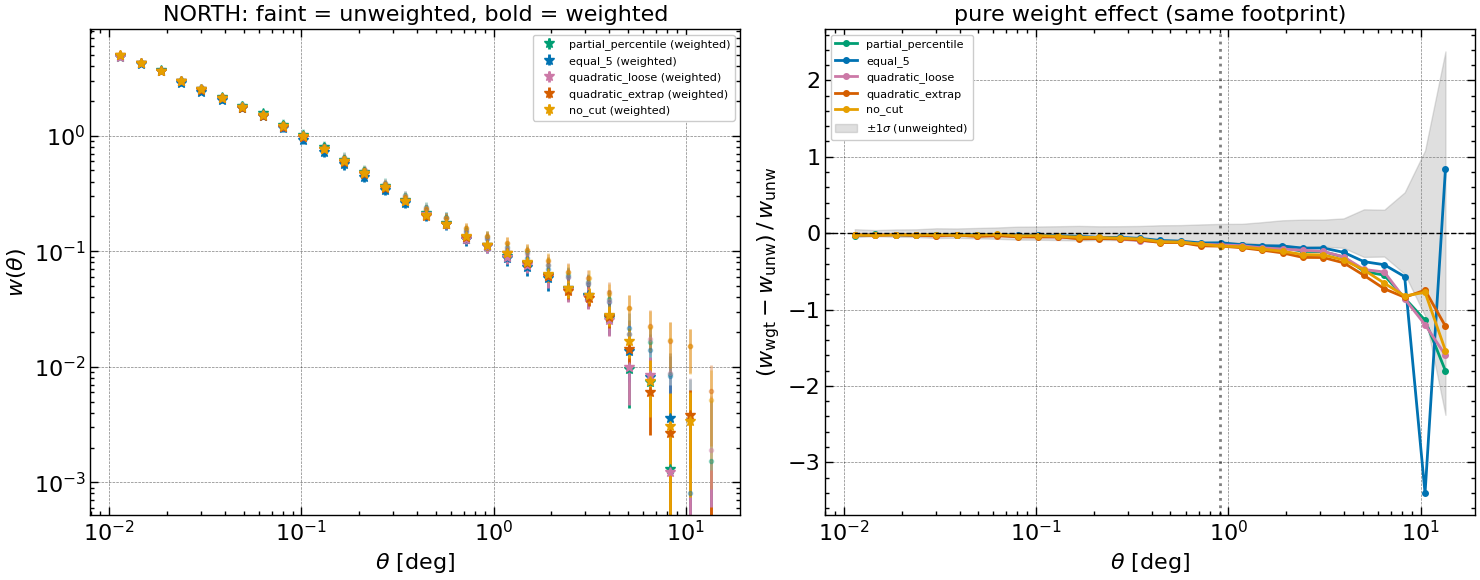

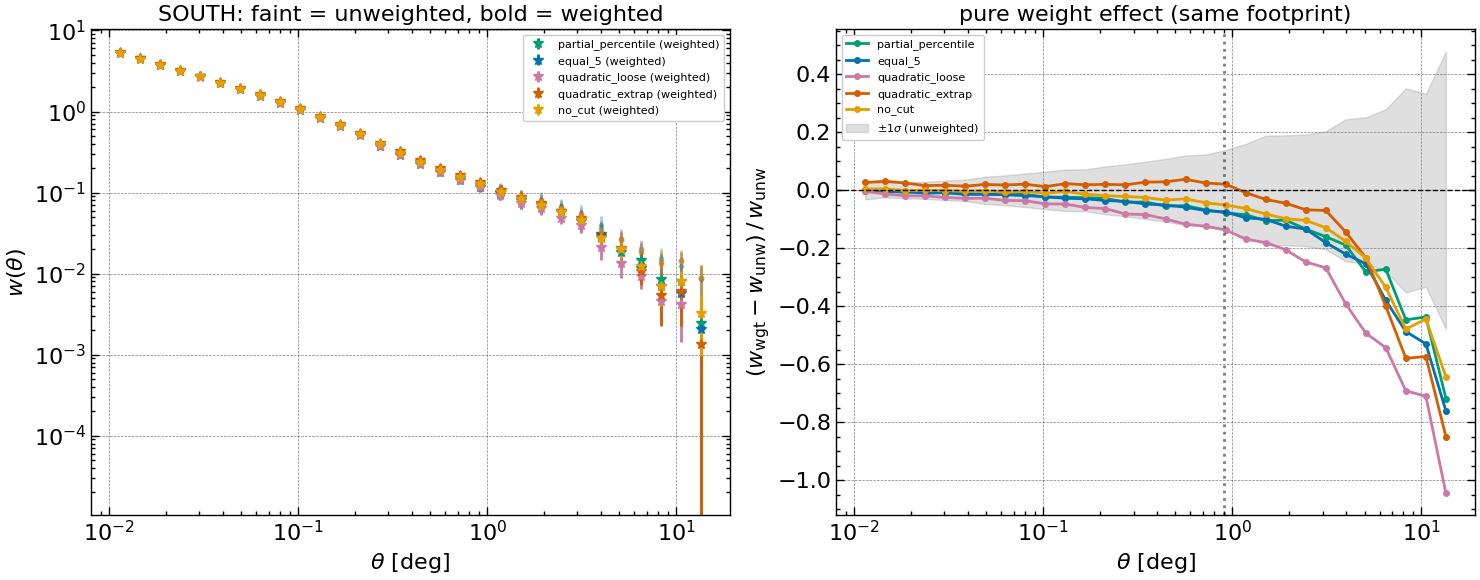

In [6]:
colors = {'partial_percentile': '#009E73', 'equal_5': '#0072B2',
          'quadratic_loose': '#CC79A7', 'no_cut': '#E69F00', 'quadratic_extrap': '#D55E00'}

for part in ('north', 'south'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for tag in SCHEMES:
        u, w = RES[part][tag]['unw'], RES[part][tag]['wgt']
        axes[0].errorbar(u['meanr'], u['xi'], yerr=u['sig'], fmt='o', ms=3,
                         color=colors[tag], alpha=0.35)
        axes[0].errorbar(w['meanr'], w['xi'], yerr=w['sig'], fmt='*', ms=7,
                         color=colors[tag], label=f'{tag} (weighted)')
        frac = (w['xi'] - u['xi']) / u['xi']
        axes[1].plot(u['meanr'], frac, 'o-', ms=4, color=colors[tag], label=tag)
    # error band from the fiducial's unweighted measurement
    u0 = RES[part]['partial_percentile']['unw']
    axes[1].fill_between(u0['meanr'], -u0['sig']/np.abs(u0['xi']),
                         u0['sig']/np.abs(u0['xi']), color='gray', alpha=0.25,
                         label=r'$\pm1\sigma$ (unweighted)')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[0].set_xlabel(r'$\theta$ [deg]'); axes[0].set_ylabel(r'$w(\theta)$')
    axes[0].set_title(f'{part.upper()}: faint = unweighted, bold = weighted')
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color='k', ls='--', lw=1)
    axes[1].axvline(SUMM_LO, color='k', ls=':', alpha=0.5)
    axes[1].set_xscale('log')
    axes[1].set_xlabel(r'$\theta$ [deg]')
    axes[1].set_ylabel(r'$(w_{\rm wgt} - w_{\rm unw})\,/\,w_{\rm unw}$')
    axes[1].set_title('pure weight effect (same footprint)')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{part}_before_after.png', dpi=200)
    plt.show()

## Footprint effect, isolated
Unweighted w(θ) on each scheme's footprint vs unweighted on the `no_cut` footprint. If schemes
differ here, the sky they remove carries different clustering — that difference is a *footprint*
choice, not a weighting choice, and it's the part you pay for with the cuts.

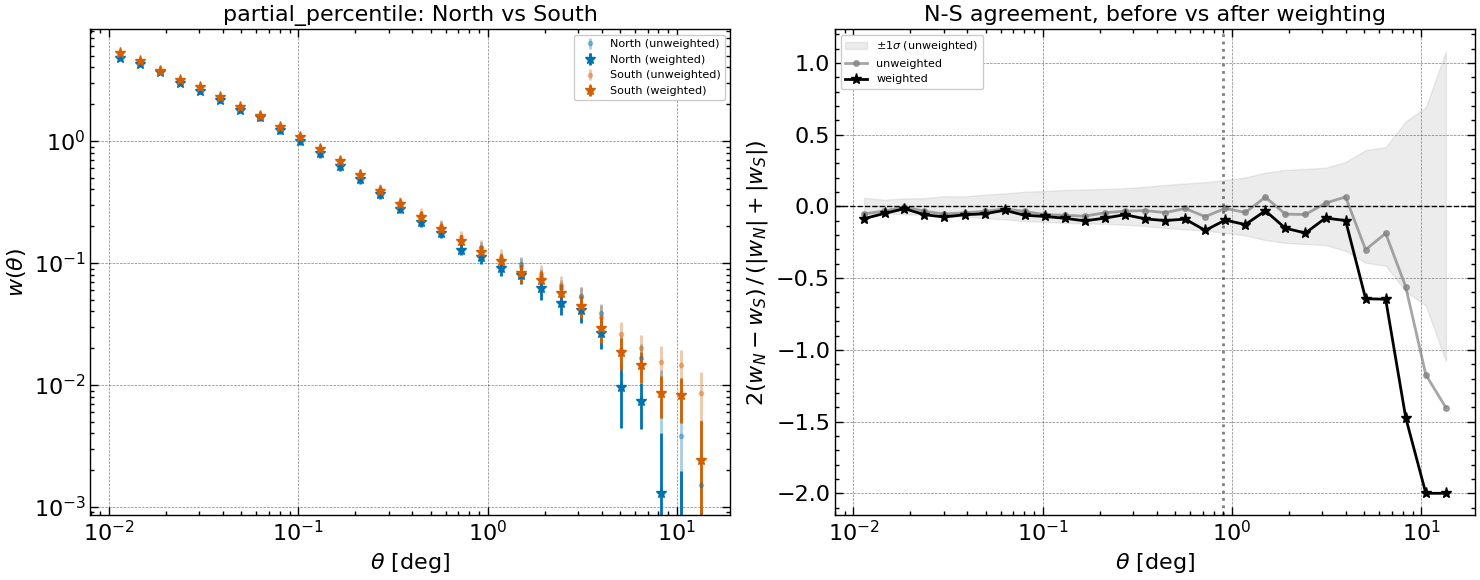

  partial_percentile:  N-S rms frac diff (>0.9deg)  unweighted=0.563  weighted=0.962  (WORSE)


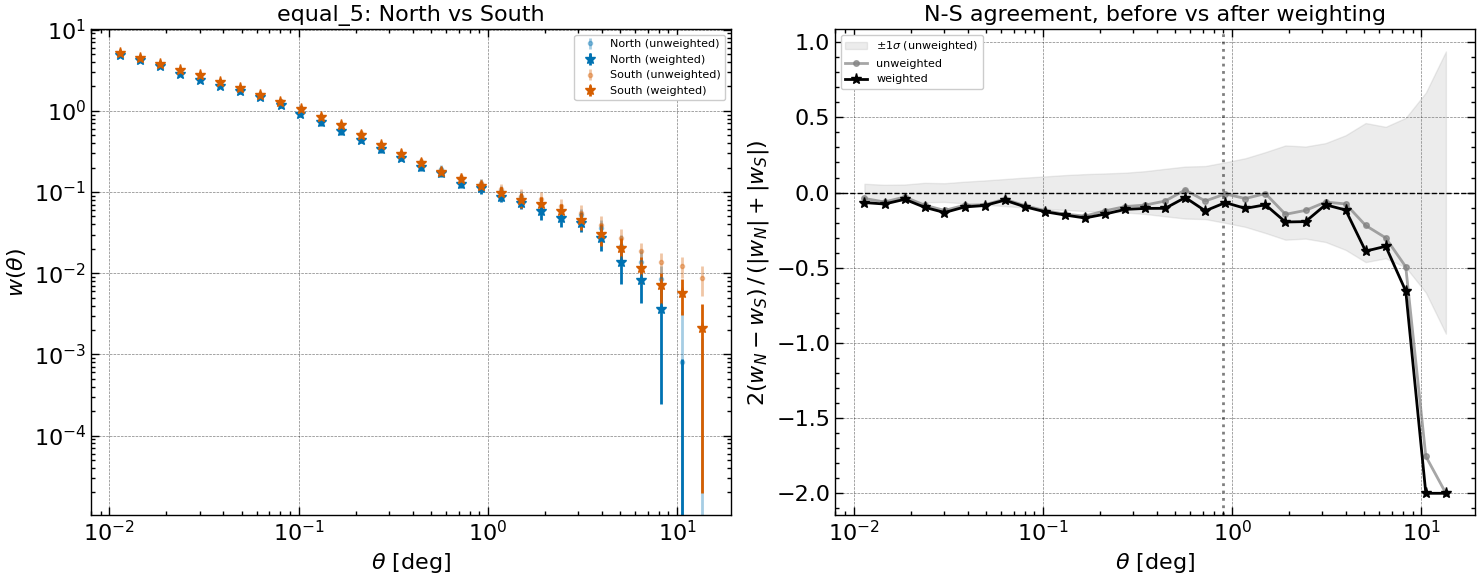

             equal_5:  N-S rms frac diff (>0.9deg)  unweighted=0.791  weighted=0.858  (WORSE)


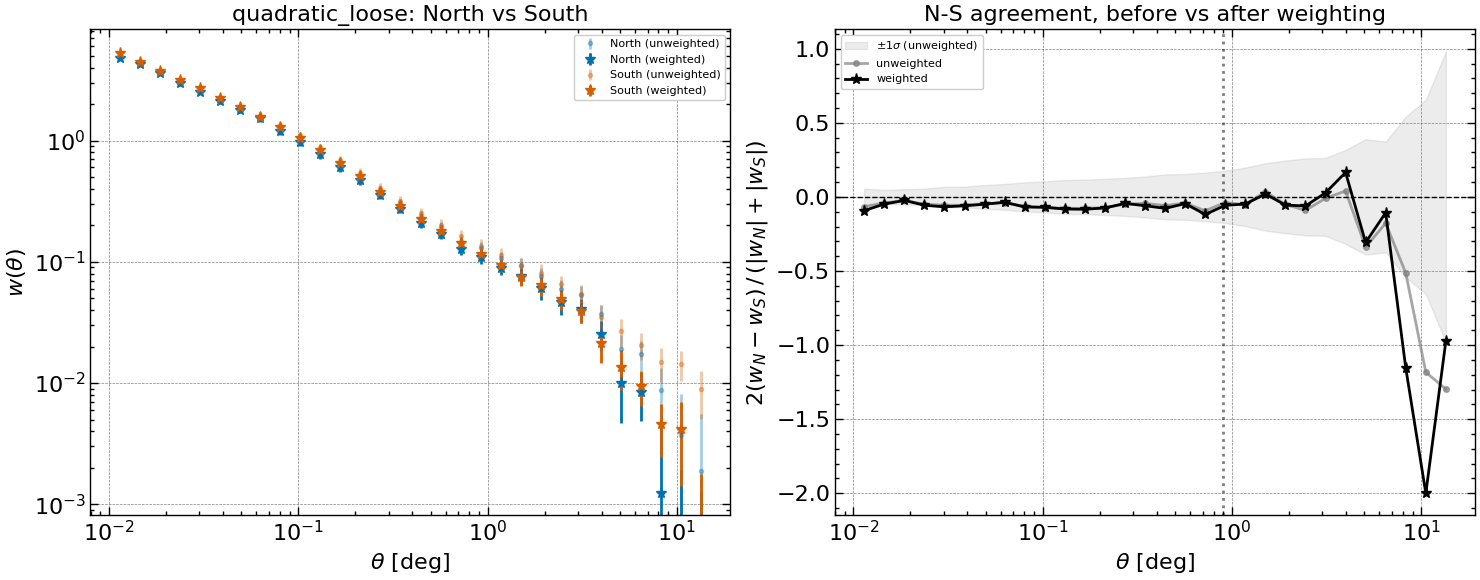

     quadratic_loose:  N-S rms frac diff (>0.9deg)  unweighted=0.541  weighted=0.731  (WORSE)


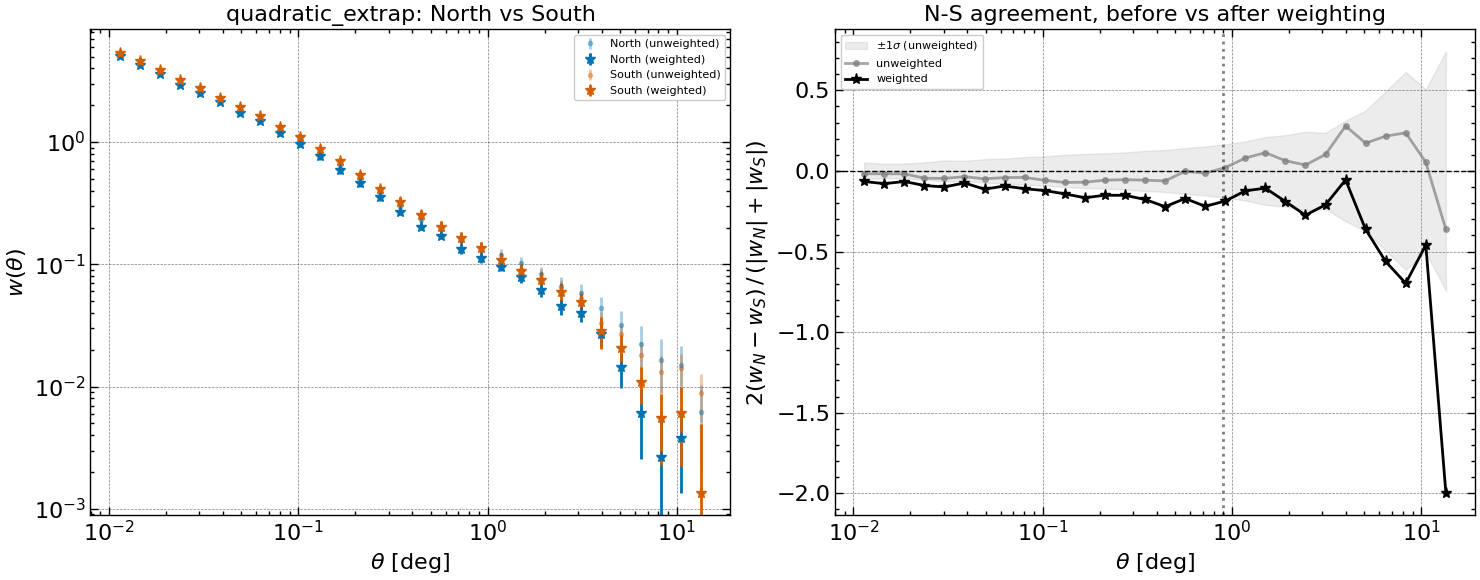

    quadratic_extrap:  N-S rms frac diff (>0.9deg)  unweighted=0.178  weighted=0.669  (WORSE)


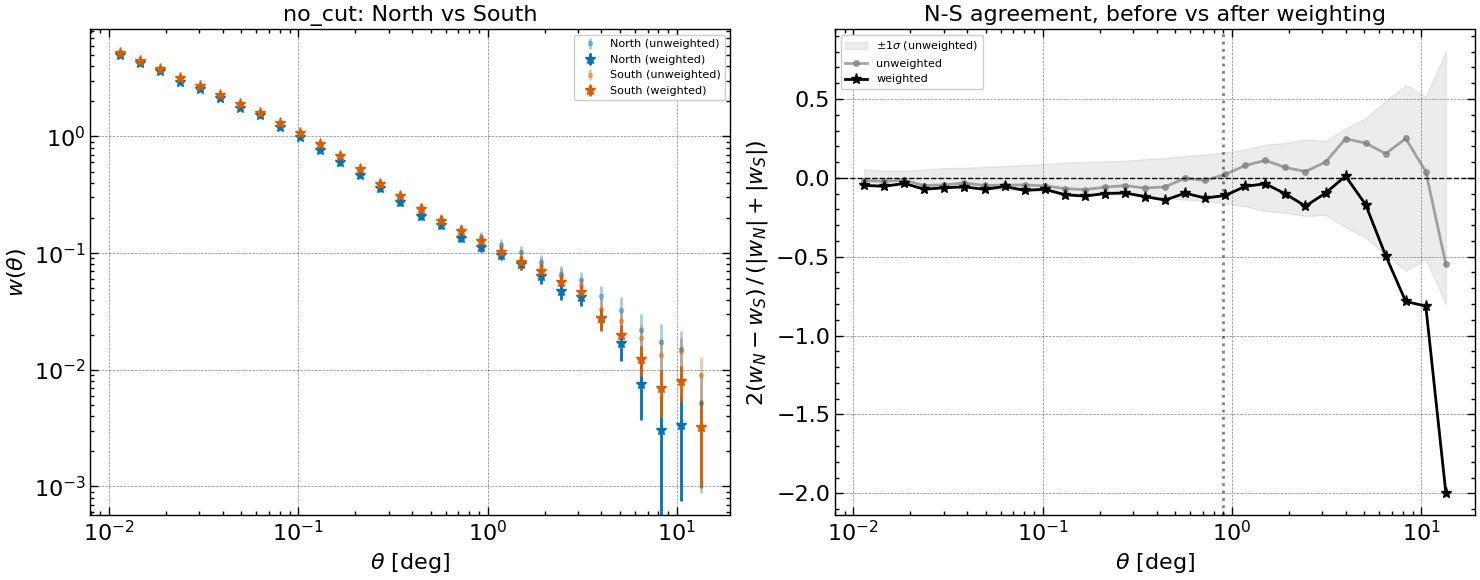

              no_cut:  N-S rms frac diff (>0.9deg)  unweighted=0.211  weighted=0.684  (WORSE)


In [7]:
for tag in SCHEMES:
    uN, wN = RES['north'][tag]['unw'], RES['north'][tag]['wgt']
    uS, wS = RES['south'][tag]['unw'], RES['south'][tag]['wgt']

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].errorbar(uN['meanr'], uN['xi'], yerr=uN['sig'], fmt='o', ms=3,
                     color='#0072B2', alpha=0.35, label='North (unweighted)')
    axes[0].errorbar(wN['meanr'], wN['xi'], yerr=wN['sig'], fmt='*', ms=8,
                     color='#0072B2', label='North (weighted)')
    axes[0].errorbar(uS['meanr'], uS['xi'], yerr=uS['sig'], fmt='o', ms=3,
                     color='#D55E00', alpha=0.35, label='South (unweighted)')
    axes[0].errorbar(wS['meanr'], wS['xi'], yerr=wS['sig'], fmt='*', ms=8,
                     color='#D55E00', label='South (weighted)')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[0].set_xlabel(r'$\theta$ [deg]'); axes[0].set_ylabel(r'$w(\theta)$')
    axes[0].set_title(f'{tag}: North vs South')
    axes[0].legend(fontsize=8)

    # fractional N-S difference, unweighted and weighted, independent-footprint errors
    def frac_diff(rN, rS):
        d = (rN['xi'] - rS['xi']) / (0.5 * (np.abs(rN['xi']) + np.abs(rS['xi'])))
        sig = np.sqrt(rN['sig']**2 + rS['sig']**2) / (0.5 * (np.abs(rN['xi']) + np.abs(rS['xi'])))
        return d, sig

    d_unw, s_unw = frac_diff(uN, uS)
    d_wgt, s_wgt = frac_diff(wN, wS)
    axes[1].fill_between(uN['meanr'], -s_unw, s_unw, color='gray', alpha=0.15,
                         label=r'$\pm1\sigma$ (unweighted)')
    axes[1].plot(uN['meanr'], d_unw, 'o-', ms=4, color='gray', alpha=0.7,
                label='unweighted')
    axes[1].plot(wN['meanr'], d_wgt, '*-', ms=8, color='k', label='weighted')
    axes[1].axhline(0, color='k', ls='--', lw=1)
    axes[1].axvline(SUMM_LO, color='k', ls=':', alpha=0.5)
    axes[1].set_xscale('log')
    axes[1].set_xlabel(r'$\theta$ [deg]')
    axes[1].set_ylabel(r'$2(w_N - w_S)\,/\,(|w_N|+|w_S|)$')
    axes[1].set_title('N-S agreement, before vs after weighting')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/NS_agreement_{tag}.png', dpi=200)
    plt.show()

    m = (uN['meanr'] > SUMM_LO) & (uN['meanr'] < SUMM_HI)
    rms_unw = np.sqrt(np.mean(d_unw[m]**2))
    rms_wgt = np.sqrt(np.mean(d_wgt[m]**2))
    print(f"{tag:>20}:  N-S rms frac diff (>{SUMM_LO}deg)  "
          f"unweighted={rms_unw:.3f}  weighted={rms_wgt:.3f}  "
          f"({'improved' if rms_wgt < rms_unw else 'WORSE'})")

In [ ]:
for part in ('north', 'south'):
    u0 = RES[part]['no_cut']['unw']
    plt.figure(figsize=(9, 5.5))
    for tag in SCHEMES:
        if tag == 'no_cut':
            continue
        u = RES[part][tag]['unw']
        plt.plot(u['meanr'], (u['xi'] - u0['xi']) / u0['xi'], 'o-', ms=4,
                 color=colors[tag], label=tag)
    plt.fill_between(u0['meanr'], -u0['sig']/np.abs(u0['xi']),
                     u0['sig']/np.abs(u0['xi']), color='gray', alpha=0.25,
                     label=r'$\pm1\sigma$ (no-cut)')
    plt.axhline(0, color='k', ls='--', lw=1)
    plt.xscale('log'); plt.xlabel(r'$\theta$ [deg]')
    plt.ylabel(r'$(w_{\rm unw}^{\rm cut} - w_{\rm unw}^{\rm nocut})/w_{\rm unw}^{\rm nocut}$')
    plt.title(f'{part.upper()}: footprint effect only (all unweighted)')
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{part}_footprint_effect.png', dpi=200)
    plt.show()

## Summary table
Averaged over the large-scale window (θ > pixel scale, where the weights operate):
mean fractional change from weighting, its significance in units of the jackknife error,
and the footprint fraction retained. The scheme whose weight effect is large *and* whose
footprint effect is small is doing the most correcting for the least sky.

In [ ]:
print(f"{'region':>7} {'scheme':>20} {'pix kept':>9} "
      f"{'<dw/w> wgt':>11} {'max|dw|/sig':>12} {'<dw/w> fpt':>11}")
summary = {}
for part in ('north', 'south'):
    ref_pix = RES[part]['no_cut']['unw']['fsky_pix']
    u0 = RES[part]['no_cut']['unw']
    for tag in SCHEMES:
        u, w = RES[part][tag]['unw'], RES[part][tag]['wgt']
        m = (u['meanr'] > SUMM_LO) & (u['meanr'] < SUMM_HI)
        dfrac_w = np.mean((w['xi'][m] - u['xi'][m]) / u['xi'][m])
        dsig    = np.max(np.abs(w['xi'][m] - u['xi'][m]) / u['sig'][m])
        dfrac_f = np.mean((u['xi'][m] - u0['xi'][m]) / u0['xi'][m])
        kept = RES[part][tag]['unw']['fsky_pix'] / ref_pix
        summary[(part, tag)] = (kept, dfrac_w, dsig, dfrac_f)
        print(f"{part:>7} {tag:>20} {kept:>8.1%} "
              f"{dfrac_w:>+10.2%} {dsig:>12.1f} {dfrac_f:>+10.2%}")

## Save

In [ ]:
for part in ('north', 'south'):
    for tag in SCHEMES:
        for kind in ('unw', 'wgt'):
            r = RES[part][tag][kind]
            np.savez(os.path.join(OUT_DIR, f'wtheta_{part}_{tag}_{kind}.npz'),
                     meanr=r['meanr'], xi=r['xi'], sig=r['sig'], cov=r['cov'],
                     n=r['n'], fsky_pix=r['fsky_pix'], seed=SEED,
                     summ_window=np.array([SUMM_LO, SUMM_HI]))
print(f"Saved {2*len(SCHEMES)*2} measurements -> {OUT_DIR}")

### Reading the results
- **Weight effect concentrated at θ ≳ 1°, suppressing power** is the expected signature —
  imaging systematics add spurious large-scale power, weights remove it. An *increase* from
  weighting, or action at θ ≪ pixel scale, would be suspicious (overcorrection or a bug).
- If `quadratic_loose` produces a weight effect similar to `partial_percentile` while its
  footprint effect is much smaller and retention much higher, it wins outright.
- Scheme-to-scheme scatter of the **weighted** w(θ) at large scales is your outlier-handling
  systematic band — quote it alongside the statistical errors in the bias fits.